[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025, Petr Krysl, pkrysl@ucsd.edu

# Penalty enforcement of supports

Last updated: 07/13/26

## Problem description

Statically determinate simply-supported truss is loaded with forces. Both the
pin and the roller, which is on an inclined plane, are enforced using a penalty
formulation with extension springs.

## References

This example is completely solved in the book Matrix Analysis of Structures by
Robert E. Sennett, ISBN 978-1577661436 (Example 7.3 on page 134).


## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


We begin with the standard imports:

In [1]:
import scipy
from math import cos, sin, pi
from numpy.linalg import norm
import context
from pystran import model
from pystran import section
from pystran import geometry 
from pystran import plots

Define a few constants:
US customary units, inches, pounds, seconds are assumed.


In [2]:
E = 29e6


The stiffness of the bars is constant. The cross sectional areas need to be
adjusted to match the stiffness.


In [3]:
kbars = 100000.0  # lb/in

The stiffness of the springs is given as a multiple of the stiffness of the
bars. Since the springs enforce the support conditions, the magnitude of the
coefficient of the springs determines the accuracy of the solution.


In [4]:
ksprings = kbars * 1000000.0  # lb/in

In [5]:
def compute_area(_m, connectivity, _E, _kbars):
    """Compute the cross sectional area so the stiffness of the bar is a constant."""
    _i, _j = _m["joints"][connectivity[0]], _m["joints"][connectivity[1]]
    L = geometry.vlen(_i["coordinates"], _j["coordinates"])
    return _kbars * L / _E

Set up the model and the joints.


In [6]:
m = model.create(2)
freedoms = m["freedoms"]
model.add_joint(m, 1, [-20 * 12, -10 * 12])
model.add_joint(m, 2, [-10 * 12, 0.0])
model.add_joint(m, 3, [0.0, -10 * 12])

Supports will be represented as springs between joints and the ground. The
ground itself will be represented as an immovable joint.


In [7]:
model.add_joint(m, "ground", [0.0, 0.0])
model.add_support(m["joints"]["ground"], freedoms.TRANSLATION_DOFS)

There are three truss bars. The cross sectional properties are computed so that
the axial stiffness is the same for all bars.


In [8]:
connectivity = [1, 2]
model.add_truss_member(
    m,
    1,
    connectivity,
    section.truss_section("s1", E=E, A=compute_area(m, connectivity, E, kbars)),
)
connectivity = [1, 3]
model.add_truss_member(
    m,
    2,
    connectivity,
    section.truss_section("s2", E=E, A=compute_area(m, connectivity, E, kbars)),
)
connectivity = [3, 2]
model.add_truss_member(
    m,
    3,
    connectivity,
    section.truss_section("s3", E=E, A=compute_area(m, connectivity, E, kbars)),
)

Since the model is so simple, we can print it to inspect all items.
Noted that each of the bars has its own section.


In [9]:
print(m)

{'dim': 2, 'freedoms': Freedoms(U1=0, U2=1, UR3=2, TRANSLATION_DOFS=(0, 1), ROTATION_DOFS=(2,), ALL_DOFS=(0, 1, 2)), 'joints': {1: {'jid': 1, 'coordinates': array([-240., -120.])}, 2: {'jid': 2, 'coordinates': array([-120.,    0.])}, 3: {'jid': 3, 'coordinates': array([   0., -120.])}, 'ground': {'jid': 'ground', 'coordinates': array([0., 0.]), 'supports': {0: 0.0, 1: 0.0}}}, 'truss_members': {1: {'mid': 1, 'connectivity': [1, 2], 'section': {'name': 's1', 'E': 29000000.0, 'rho': 0.0, 'CTE': 0.0, 'A': np.float64(0.5851918189130049)}}, 2: {'mid': 2, 'connectivity': [1, 3], 'section': {'name': 's2', 'E': 29000000.0, 'rho': 0.0, 'CTE': 0.0, 'A': np.float64(0.8275862068965517)}}, 3: {'mid': 3, 'connectivity': [3, 2], 'section': {'name': 's3', 'E': 29000000.0, 'rho': 0.0, 'CTE': 0.0, 'A': np.float64(0.5851918189130049)}}}}


There are two forces at the top.


In [10]:
model.add_load(m["joints"][2], freedoms.U1, 10)
model.add_load(m["joints"][2], freedoms.U2, 5)

The supports are enforced using extension springs. The springs are attached to
the ground.


In [11]:
model.add_spring_member(
    m, 1, [1, "ground"], section.spring_section("ss1", "extension", [1, 0], ksprings)
)
model.add_spring_member(
    m, 2, [1, "ground"], section.spring_section("ss2", "extension", [0, 1], ksprings)
)
model.add_spring_member(
    m, 3, [3, "ground"],
    section.spring_section(
        "ss3", "extension", [-cos(30 / 180 * pi), sin(30 / 180 * pi)], ksprings
    ),
)

Now we can solve the static equilibrium of the frame.


In [12]:
model.number_dofs(m)
model.solve_statics(m)

The displacements of the joints can be printed out. Recall that joint 1 is
supposed to be pinned, and its displacement should vanish. Joint 2 is
supported by an inclined roller. Note that the displacements need to be scaled
by our particular value of the bar stiffness so that we can compare with the
book.


In [13]:
for jid in [1, 2, 3]:
    j = m["joints"][jid]
    print(jid, kbars * j["displacements"])

1 [5.66987298e-06 7.50000000e-06]
2 [10.66988249  4.33013068]
3 [-1.83012135 -3.16987316]


In [14]:
if norm(kbars * m["joints"][1]["displacements"]) > 1e-3:
    print("Displacements at 1 wrong")
if norm(kbars * m["joints"][2]["displacements"] - [10.66988249, 4.33013068]) > 1e-3:
    print("Displacements at 2 wrong")
if norm(kbars * m["joints"][3]["displacements"] - [-1.83012135, -3.16987316]) > 1e-3:
    print("Displacements at 3 wrong")

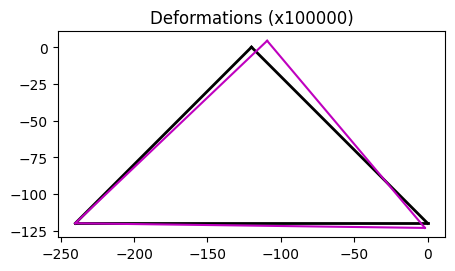

In [15]:
ax = plots.setup(m)
plots.plot_members(m)
ax = plots.plot_deformations(m, 100000.0)
ax.set_title("Deformations (x100000)")
plots.show(m)

## Conclusions

We show that prescribed zero-displacement conditions can be enforced with springs to ground. Either in the global cartesian  coordinate directions or at an arbitrarily inclined direction.
